# 02 — Aumento de dados melhora a generalização?

**Experimento local inspirado** nas §§2 e 4.2 de [Yang et al.](https://arxiv.org/abs/2204.08610v2). O survey usa CIFAR-10, CIFAR-100 e SVHN com outras redes; estes resultados MNIST **não reproduzem suas acurácias**.

Protocolo fixado antes da execução: 2.000 exemplos de treino (200/classe), 1.000 de validação (100/classe) e 2.000 de teste oficial (200/classe). MLP 784→128→10, Adam, 15 épocas, lote 128, três sementes. Cada política recebe a mesma inicialização, exemplos, ordem dos lotes e número de atualizações. A validação registra a curva; avaliamos o modelo da última época, sem escolher épocas ou políticas pelo teste.

Teste limpo e teste com translação fixa de 3 pixels medem, respectivamente, generalização no domínio e robustez à perturbação. O teste deslocado é derivado dos mesmos exemplos, não é uma amostra independente.

O notebook reutiliza o MNIST do seminário 1; em uma cópia nova permite o download oficial (~12 MB).

In [1]:
from pathlib import Path
import os
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'
import csv
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'seminar_3/articles').is_dir())
SEMINAR = ROOT / 'seminar_3'
OUT = SEMINAR / 'data/outputs'
PROCESSED = SEMINAR / 'data/processed'
OUT.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

def save_csv(path, rows):
    with path.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

In [2]:
import time
import platform
import torch
from torch import nn
from torchvision.datasets import MNIST
import albumentations as A
import cv2

torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
DATA = ROOT / 'seminar_1/data/mnist/source'
train_data = MNIST(DATA, train=True, download=True)
test_data = MNIST(DATA, train=False, download=True)
split_rng = np.random.default_rng(558)
train_ids, val_ids, test_ids = [], [], []
for digit in range(10):
    ids = split_rng.permutation(np.flatnonzero(train_data.targets.numpy() == digit))
    train_ids.extend(ids[:200]); val_ids.extend(ids[200:300])
    ids_test = split_rng.permutation(np.flatnonzero(test_data.targets.numpy() == digit))
    test_ids.extend(ids_test[:200])
assert set(train_ids).isdisjoint(val_ids)
np.savez_compressed(PROCESSED / 'mnist_split.npz', train=train_ids, validation=val_ids, test=test_ids)
raw_train = train_data.data[train_ids].numpy()
x_train = torch.tensor(raw_train / 255, dtype=torch.float32).unsqueeze(1)
y_train = train_data.targets[train_ids]
x_val = train_data.data[val_ids].float().unsqueeze(1) / 255
y_val = train_data.targets[val_ids]
x_test = test_data.data[test_ids].float().unsqueeze(1) / 255
y_test = test_data.targets[test_ids]
x_shift = torch.zeros_like(x_test)
x_shift[:, :, :, 3:] = x_test[:, :, :, :-3]  # Sem wrap-around.
assert x_shift[:, :, :, :3].count_nonzero() == 0
print('Treino/validação/teste:', len(x_train), len(x_val), len(x_test))

Treino/validação/teste: 2000 1000 2000


## Políticas e controles
- **Sem augmentation:** referência.
- **Affine leve:** rotação até 12°, translação até 10%, escala 0,9–1,1.
- **Cutout:** um quadrado 6×6 por imagem.
- **Mixup:** λ ~ Beta(0,4; 0,4), perda ponderada para os dois rótulos.
- **Rotação 180°:** controle de transformação potencialmente inválida, aplicada em 50% das imagens sem corrigir rótulos.

A amplitude é ajustável. Não há garantia de que todas as políticas melhorem o resultado. `Compose(seed=...)` é criado uma vez por execução: assim a sequência é repetível, mas muda entre as chamadas.

In [3]:
SEEDS = [7, 23, 42]
EPOCHS = 15
BATCH = 128
POLICIES = ['Sem augmentation', 'Affine leve', 'Cutout', 'Mixup', 'Rotacao 180']

@torch.inference_mode()
def accuracy(model, images, labels):
    model.eval()
    return (model(images).argmax(1) == labels).float().mean().item() * 100

rows, curves = [], []
for seed in SEEDS:
    for policy in POLICIES:
        torch.manual_seed(seed)
        rng = np.random.default_rng(seed)
        order_rng = np.random.default_rng(seed + 1000)
        affine = A.Compose([A.Affine(scale=(0.9, 1.1), translate_percent=(-0.1, 0.1),
                                     rotate=(-12, 12), border_mode=cv2.BORDER_CONSTANT, p=1)], seed=seed)
        model = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        started = time.perf_counter()
        for epoch in range(EPOCHS):
            model.train()
            order = order_rng.permutation(len(x_train))
            loss_total = 0.0
            for start in range(0, len(order), BATCH):
                ids = order[start:start+BATCH]
                xb, yb = x_train[ids].clone(), y_train[ids]
                if policy == 'Affine leve':
                    augmented = np.stack([affine(image=im)['image'] for im in raw_train[ids]])
                    xb = torch.tensor(augmented / 255, dtype=torch.float32).unsqueeze(1)
                elif policy == 'Cutout':
                    for i in range(len(xb)):
                        top, left = rng.integers(0, 23, size=2)
                        xb[i, :, top:top+6, left:left+6] = 0
                elif policy == 'Rotacao 180':
                    selected = rng.random(len(xb)) < 0.5
                    xb[selected] = torch.rot90(xb[selected], 2, (-2, -1))
                optimizer.zero_grad()
                if policy == 'Mixup':
                    lam = float(rng.beta(0.4, 0.4))
                    pair = rng.permutation(len(xb))
                    logits = model(lam*xb + (1-lam)*xb[pair])
                    loss = lam*nn.functional.cross_entropy(logits, yb) + (1-lam)*nn.functional.cross_entropy(logits, yb[pair])
                else:
                    loss = nn.functional.cross_entropy(model(xb), yb)
                loss.backward(); optimizer.step()
                loss_total += loss.item() * len(ids)
            assert np.isfinite(loss_total)
            curves.append(dict(seed=seed, policy=policy, epoch=epoch+1,
                               train_loss=loss_total/len(x_train),
                               train_accuracy=accuracy(model, x_train, y_train),
                               val_accuracy=accuracy(model, x_val, y_val)))
        elapsed = time.perf_counter() - started
        row = dict(seed=seed, policy=policy, train_accuracy=accuracy(model, x_train, y_train),
                   test_accuracy=accuracy(model, x_test, y_test),
                   shifted_accuracy=accuracy(model, x_shift, y_test), seconds=elapsed)
        rows.append(row)
        print(f"seed={seed:2} | {policy:17} | teste={row['test_accuracy']:.2f}% | deslocado={row['shifted_accuracy']:.2f}%")
        save_csv(OUT / 'mnist_results.csv', rows)
        save_csv(OUT / 'mnist_curves.csv', curves)
assert len(rows) == len(SEEDS)*len(POLICIES)
assert all(0 <= r['test_accuracy'] <= 100 for r in rows)
assert all(r['test_accuracy'] > 60 for r in rows if r['policy'] == 'Sem augmentation')

seed= 7 | Sem augmentation  | teste=89.75% | deslocado=39.70%


seed= 7 | Affine leve       | teste=88.65% | deslocado=65.80%


seed= 7 | Cutout            | teste=89.40% | deslocado=39.10%


seed= 7 | Mixup             | teste=89.15% | deslocado=39.10%


seed= 7 | Rotacao 180       | teste=83.40% | deslocado=45.00%


...

seed=42 | Sem augmentation  | teste=90.35% | deslocado=39.80%


seed=42 | Affine leve       | teste=90.45% | deslocado=65.15%


seed=42 | Cutout            | teste=89.85% | deslocado=40.25%


seed=42 | Mixup             | teste=88.55% | deslocado=39.45%


seed=42 | Rotacao 180       | teste=83.00% | deslocado=43.60%


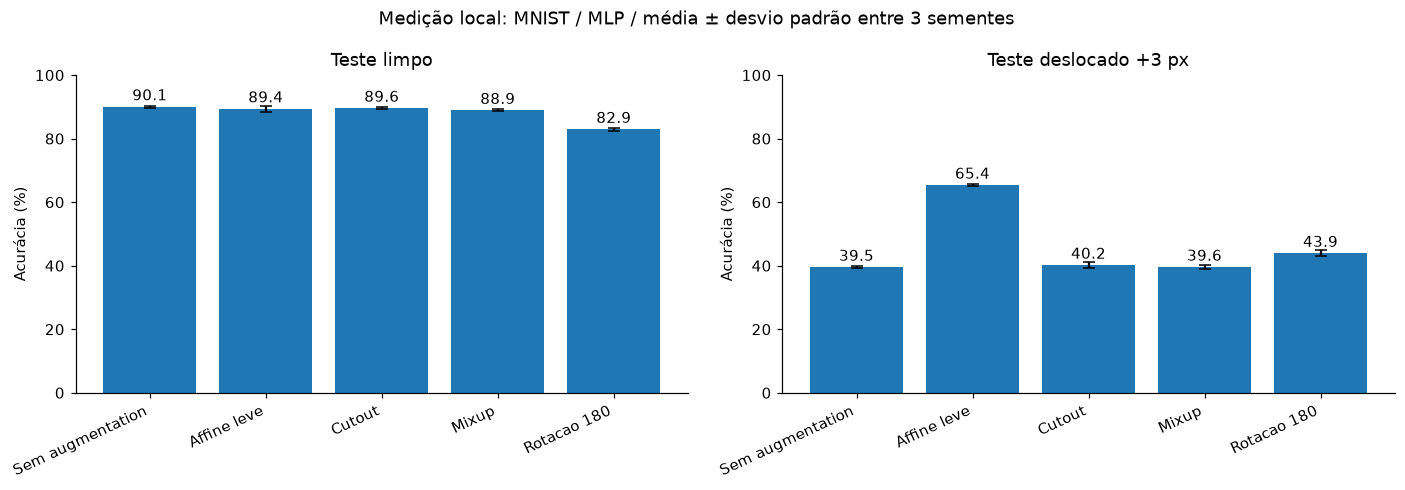

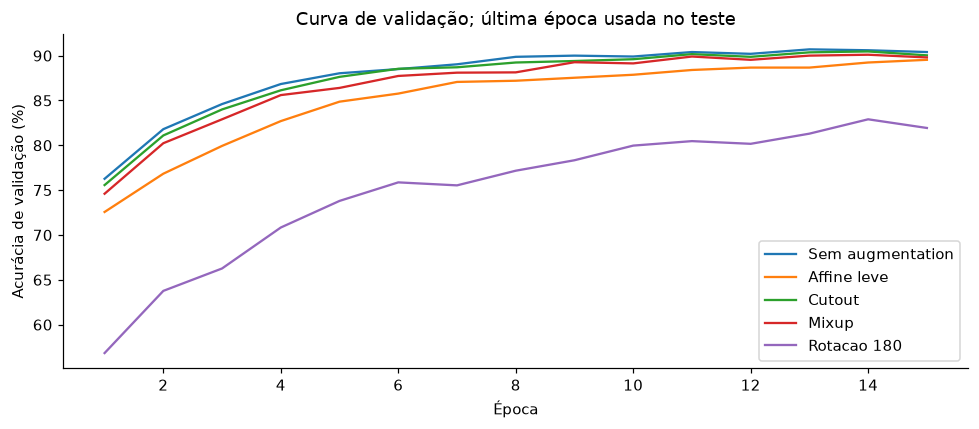

Affine leve: diferença pareada no teste = -0.65 ± 0.65 p.p.
Cutout: diferença pareada no teste = -0.47 ± 0.10 p.p.
Mixup: diferença pareada no teste = -1.15 ± 0.61 p.p.
Rotacao 180: diferença pareada no teste = -7.12 ± 0.68 p.p.


457

In [4]:
summary = []
for policy in POLICIES:
    selected = [r for r in rows if r['policy'] == policy]
    summary.append(dict(policy=policy, **{
        key+suffix: float(fn([r[key] for r in selected]))
        for key in ['test_accuracy', 'shifted_accuracy']
        for suffix, fn in [('_mean', np.mean), ('_std', lambda a: np.std(a, ddof=1))]
    }))
save_csv(OUT / 'mnist_summary.csv', summary)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric, title in zip(axes, ['test_accuracy', 'shifted_accuracy'], ['Teste limpo', 'Teste deslocado +3 px'], strict=True):
    means = [s[metric+'_mean'] for s in summary]
    ax.bar(range(len(POLICIES)), means, yerr=[s[metric+'_std'] for s in summary], capsize=4)
    ax.set_xticks(range(len(POLICIES)), POLICIES, rotation=25, ha='right')
    ax.set(ylabel='Acurácia (%)', ylim=(0, 100), title=title)
    for i, value in enumerate(means): ax.text(i, value+2, f'{value:.1f}', ha='center')
fig.suptitle('Medição local: MNIST / MLP / média ± desvio padrão entre 3 sementes')
fig.tight_layout()
fig.savefig(OUT / 'mnist_accuracy.png', bbox_inches='tight')
plt.show()
fig, ax = plt.subplots(figsize=(9, 4))
for policy in POLICIES:
    mean_curve = [np.mean([r['val_accuracy'] for r in curves if r['policy']==policy and r['epoch']==epoch]) for epoch in range(1, EPOCHS+1)]
    ax.plot(range(1, EPOCHS+1), mean_curve, label=policy)
ax.set(xlabel='Época', ylabel='Acurácia de validação (%)', title='Curva de validação; última época usada no teste')
ax.legend(); fig.tight_layout(); fig.savefig(OUT / 'mnist_learning.png', bbox_inches='tight'); plt.show()
for policy in POLICIES[1:]:
    delta = [next(r['test_accuracy'] for r in rows if r['seed']==s and r['policy']==policy)
             - next(r['test_accuracy'] for r in rows if r['seed']==s and r['policy']==POLICIES[0]) for s in SEEDS]
    print(f'{policy}: diferença pareada no teste = {np.mean(delta):+.2f} ± {np.std(delta, ddof=1):.2f} p.p.')
metadata = dict(dataset='MNIST', train=2000, validation=1000, test=2000, split_seed=558,
                seeds=SEEDS, epochs=EPOCHS, batch=BATCH, device='cpu', threads=2,
                model='Flatten-Linear(784,128)-ReLU-Linear(128,10)', optimizer='Adam lr=0.001',
                python=platform.python_version(), torch=torch.__version__, albumentations=A.__version__,
                numpy=np.__version__, platform=platform.platform())
(OUT / 'mnist_protocol.json').write_text(json.dumps(metadata, indent=2))

## Interpretação e limites
Compare o ganho pareado no teste limpo, a robustez ao deslocamento e a curva de validação. A barra mostra desvio entre sementes, **não intervalo de confiança**; três execuções no mesmo split não estabelecem significância estatística.

A diferença treino–teste pode indicar sobreajuste, mas não é uma prova isolada. O controle de rotação demonstra o risco semântico de aumentar dados indiscriminadamente. Para aproximar o protocolo do survey, seria necessário trocar dados e modelos e obter políticas, magnitudes e detalhes de treino completos. Não atribua o melhor resultado local aos modelos do artigo.